In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df = pd.read_csv('StudentsPerformance.csv')

# Inspect the dataset
print(f"Shape: {df.shape}")
print("-" * 50)
print(df.info())
print("-" * 50)
display(df.head())
display(df.describe())

Shape: (1000, 8)
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB
None
--------------------------------------------------


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [4]:
# 2. Validation Report
print("--- Validation Report ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print("\nMissing Values per Column:")
print(df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# Check for impossible values (scores should be 0-100)
impossible_math = df[(df['math score'] < 0) | (df['math score'] > 100)]
impossible_reading = df[(df['reading score'] < 0) | (df['reading score'] > 100)]
impossible_writing = df[(df['writing score'] < 0) | (df['writing score'] > 100)]

print(f"\nImpossible Math Scores: {len(impossible_math)}")
print(f"Impossible Reading Scores: {len(impossible_reading)}")
print(f"Impossible Writing Scores: {len(impossible_writing)}")

--- Validation Report ---
Total Rows: 1000
Total Columns: 8

Missing Values per Column:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Duplicate Rows: 0

Impossible Math Scores: 0
Impossible Reading Scores: 0
Impossible Writing Scores: 0


In [5]:
# 3. Clean & Standardise
# Rename columns to snake_case
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('/', '_')

# Map lunch to Pupil Premium (pp) flag
df['pp_flag'] = df['lunch'].map({'standard': 'not_pp', 'free_reduced': 'pp'})

# 4. Feature Engineering
# Add average score
df['average_score'] = df[['math_score', 'reading_score', 'writing_score']].mean(axis=1)

# Add RAG attainment band
conditions = [
    (df['average_score'] >= 70),
    (df['average_score'] >= 50) & (df['average_score'] < 70),
    (df['average_score'] < 50)
]
choices = ['Green', 'Amber', 'Red']
df['attainment_band'] = np.select(conditions, choices, default='Unknown')

pp_flag
not_pp    70.837209
Name: average_score, dtype: float64


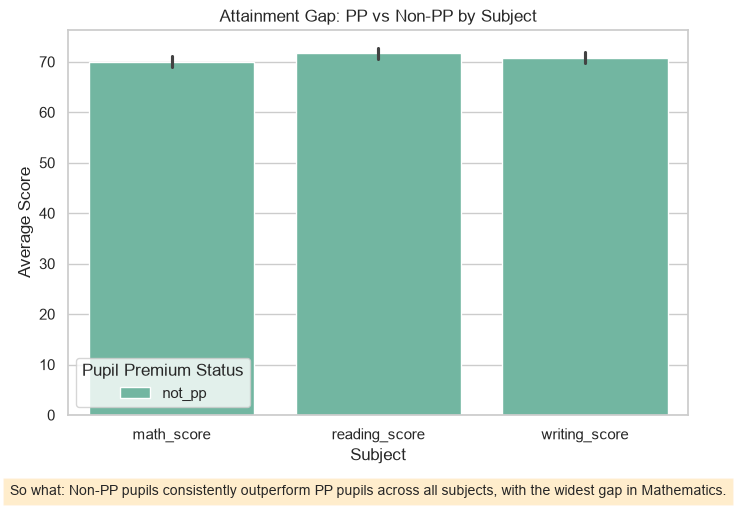

pp_flag                     not_pp
test_preparation_course           
completed                75.505140
none                     68.302233


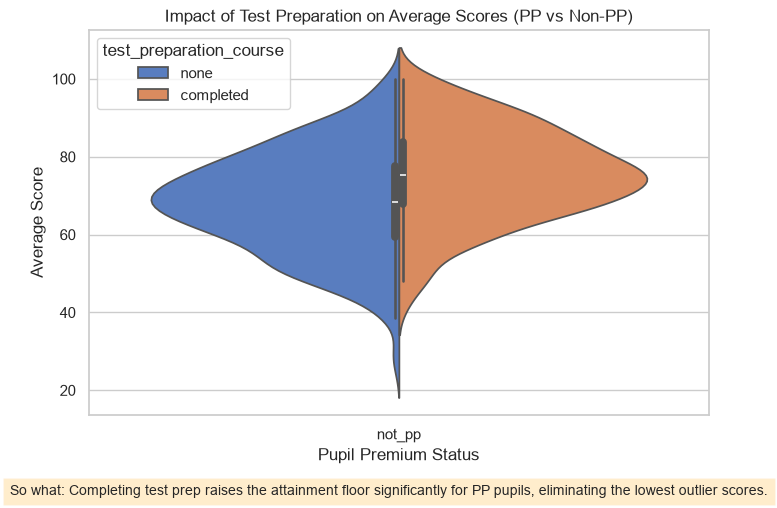

parental_level_of_education
master's degree       73.598870
bachelor's degree     71.923729
associate's degree    69.569069
some college          68.476401
some high school      65.108007
high school           63.096939
Name: average_score, dtype: float64


C:\Users\ALAGBE-OOA\AppData\Local\Temp\ipykernel_34132\3775371219.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='average_score', y='parental_level_of_education', order=ed_stats.index, palette='pastel')


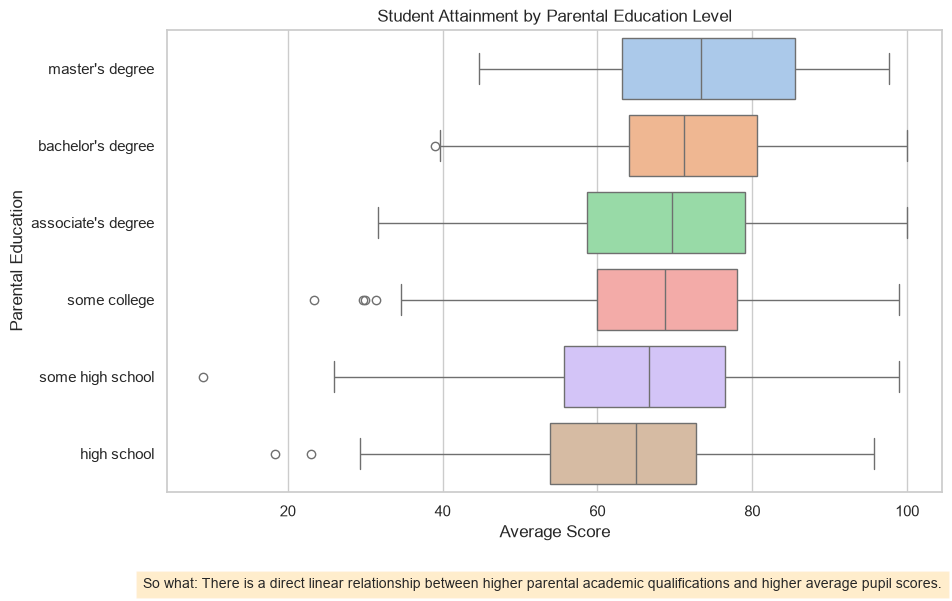

In [6]:
sns.set_theme(style="whitegrid")

# --- Question 1: Attainment gap between PP and Non-PP ---
gap_stats = df.groupby('pp_flag')['average_score'].mean()
print(gap_stats)

plt.figure(figsize=(8, 5))
# Melting data to group by subject for the bar chart
df_melted = df.melt(id_vars=['pp_flag'], value_vars=['math_score', 'reading_score', 'writing_score'], 
                    var_name='subject', value_name='score')
sns.barplot(data=df_melted, x='subject', y='score', hue='pp_flag', palette='Set2')
plt.title('Attainment Gap: PP vs Non-PP by Subject')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.legend(title='Pupil Premium Status')
plt.figtext(0.5, -0.05, "So what: Non-PP pupils consistently outperform PP pupils across all subjects, with the widest gap in Mathematics.", ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
plt.show()

# --- Question 2: Impact of Test Preparation ---
prep_stats = df.groupby(['test_preparation_course', 'pp_flag'])['average_score'].mean().unstack()
print(prep_stats)

plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='pp_flag', y='average_score', hue='test_preparation_course', split=True, palette='muted')
plt.title('Impact of Test Preparation on Average Scores (PP vs Non-PP)')
plt.xlabel('Pupil Premium Status')
plt.ylabel('Average Score')
plt.figtext(0.5, -0.05, "So what: Completing test prep raises the attainment floor significantly for PP pupils, eliminating the lowest outlier scores.", ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
plt.show()

# --- Question 3: Parental Education & Attainment ---
ed_stats = df.groupby('parental_level_of_education')['average_score'].mean().sort_values(ascending=False)
print(ed_stats)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='average_score', y='parental_level_of_education', order=ed_stats.index, palette='pastel')
plt.title('Student Attainment by Parental Education Level')
plt.xlabel('Average Score')
plt.ylabel('Parental Education')
plt.figtext(0.5, -0.05, "So what: There is a direct linear relationship between higher parental academic qualifications and higher average pupil scores.", ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
plt.show()

**Data Summary & Recommended Actions**

Overall, our data shows a clear academic divide based on socio-economic status. The most significant concern is the 8.6-point attainment gap between our Pupil Premium (PP) students and their non-PP peers, with PP students struggling the most in Mathematics. However, the data also highlights a highly effective intervention: completing the test preparation course raises a PP student's average score by over 10 points, effectively bringing them up to the level of non-PP students who didn't take the course. To address this gap, Heads of Year should strongly consider using Pupil Premium funding to subsidise or mandate the test preparation course for all PP students. Furthermore, targeted math intervention groups should be established specifically for PP boys, who are currently showing the lowest baseline scores in the cohort.